# Cell Ranger Multi GEX + VDJ + CSP — Post-Processing Analysis

In this notebook we will upload the `sc-preprocess` produced and make some quick observations.

- **Dataset:** [Human PBMC from a Healthy Donor, 10k cells, Multi v2.2 — Cell Ranger 5.0.0](https://www.10xgenomics.com/datasets/human-pbmc-from-a-healthy-donor-10-k-cells-multi-v-2-2-standard-5-0-0)  
- **Modality:** 5' GEX + TCR (VDJ-T) + BCR (VDJ-B) + Cell Surface Protein  
- **Output:** `gex` + `airr` (TCR+BCR merged) + `prot`; `cell_id = {batch}_{capture}_{barcode}`

## Setup

Set `H5MU_PATH` to the path of your pipeline output file.

In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import muon as mu
import scanpy as sc
import scirpy as ir
import matplotlib.pyplot as plt

# Path to the final pipeline output — update this to match your output directory
H5MU_PATH = "../GEX_VDJ_CSP/GEX_VDJ_CSP/07_FINAL/1_multi.h5mu"

## Load the data

In [4]:
mdata = mu.read(H5MU_PATH)
mdata

/project/lbarreiro/USERS/mschechter/miniconda3/envs/snakemake8/lib/python3.12/site-packages/anndata/utils.py:362: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)


MuData object with n_obs × n_vars = 10617 × 38625
  obs:	'batch_id', 'capture_id', 'cell_id'
  3 modalities
    prot:	10617 x 19
      obs:	'batch_id', 'capture_id', 'cell_id'
      var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
    gex:	10617 x 38606
      obs:	'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'batch_id', 'capture_id', 'cell_id'
      var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    airr:	6158 x 0
      obs:	'batch_id', 'capture_id', 'cell_id', 'receptor_type', 'receptor_subtype', 'chain_pairing'
      obsm:	'airr', 'chain_indices'

## Verify traceability metadata

Every cell should have `batch_id`, `capture_id`, and a globally unique `cell_id`.

In [5]:
assert "batch_id" in mdata.obs.columns
assert "capture_id" in mdata.obs.columns
assert "cell_id" in mdata.obs.columns
assert mdata.obs["cell_id"].is_unique, "cell_id must be unique!"

print(f"Total cells : {mdata.n_obs}")
print(f"Modalities  : {list(mdata.mod.keys())}")
print(f"GEX shape   : {mdata['gex'].shape}")
print()
print(mdata.obs[["batch_id", "capture_id", "cell_id"]].head())

Total cells : 10617
Modalities  : ['prot', 'gex', 'airr']
GEX shape   : (10617, 38606)

                   batch_id capture_id                 cell_id
AAACCTGAGACAGACC-1        1          A  1_A_AAACCTGAGACAGACC-1
AAACCTGAGCGATAGC-1        1          A  1_A_AAACCTGAGCGATAGC-1
AAACCTGAGCGGCTTC-1        1          A  1_A_AAACCTGAGCGGCTTC-1
AAACCTGAGGATCGCA-1        1          A  1_A_AAACCTGAGGATCGCA-1
AAACCTGAGTCACGCC-1        1          A  1_A_AAACCTGAGTCACGCC-1


## GEX quality control

Key metrics to inspect:
- `total_counts` — total UMI counts per cell
- `n_genes_by_counts` — number of detected genes per cell
- `pct_counts_mt` — percent mitochondrial counts (high values indicate damaged cells)

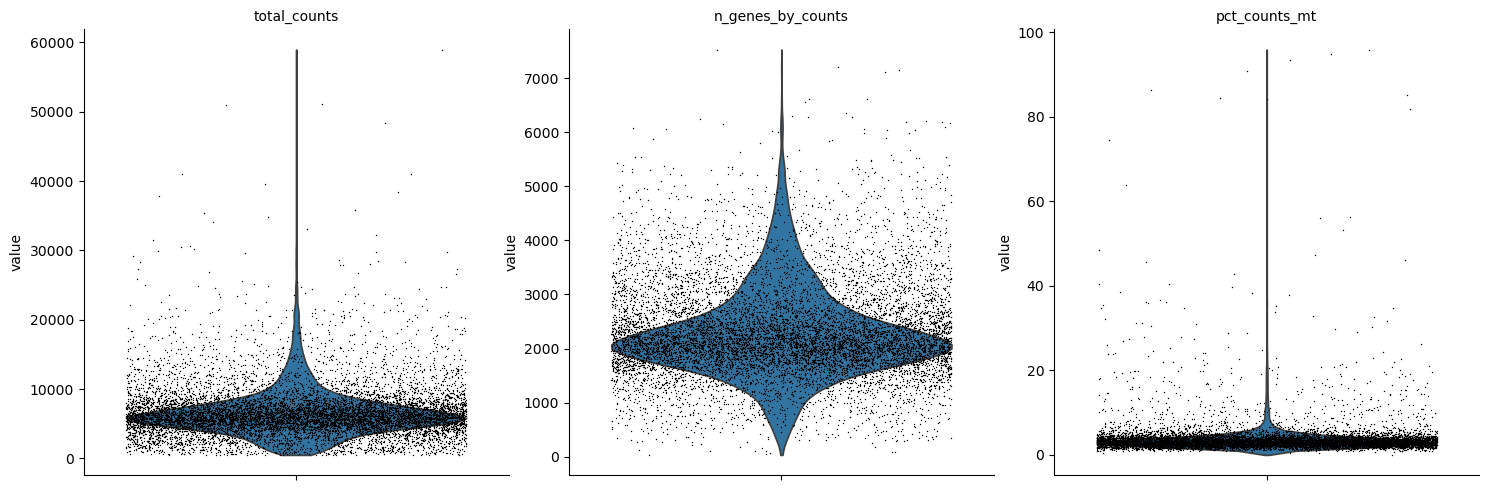

In [6]:
sc.pl.violin(
    mdata["gex"],
    ["total_counts", "n_genes_by_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

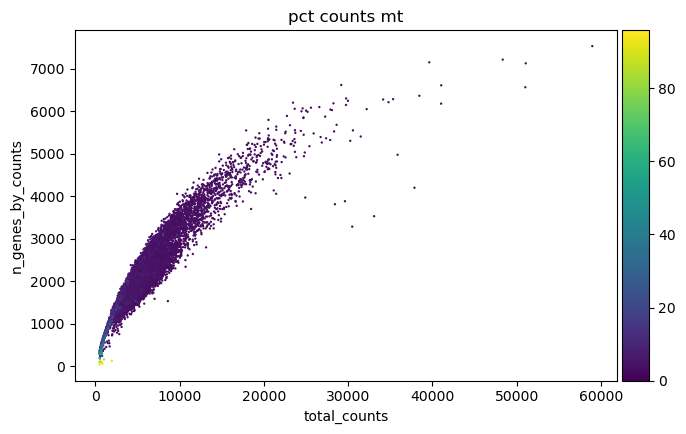

In [7]:
sc.pl.scatter(
    mdata["gex"],
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_mt",
)

## Visualize cells with detected BCR

In [8]:
sc.pp.log1p(mdata["gex"])
sc.pp.pca(mdata["gex"], svd_solver="arpack")
sc.pp.neighbors(mdata["gex"])
sc.tl.umap(mdata["gex"])

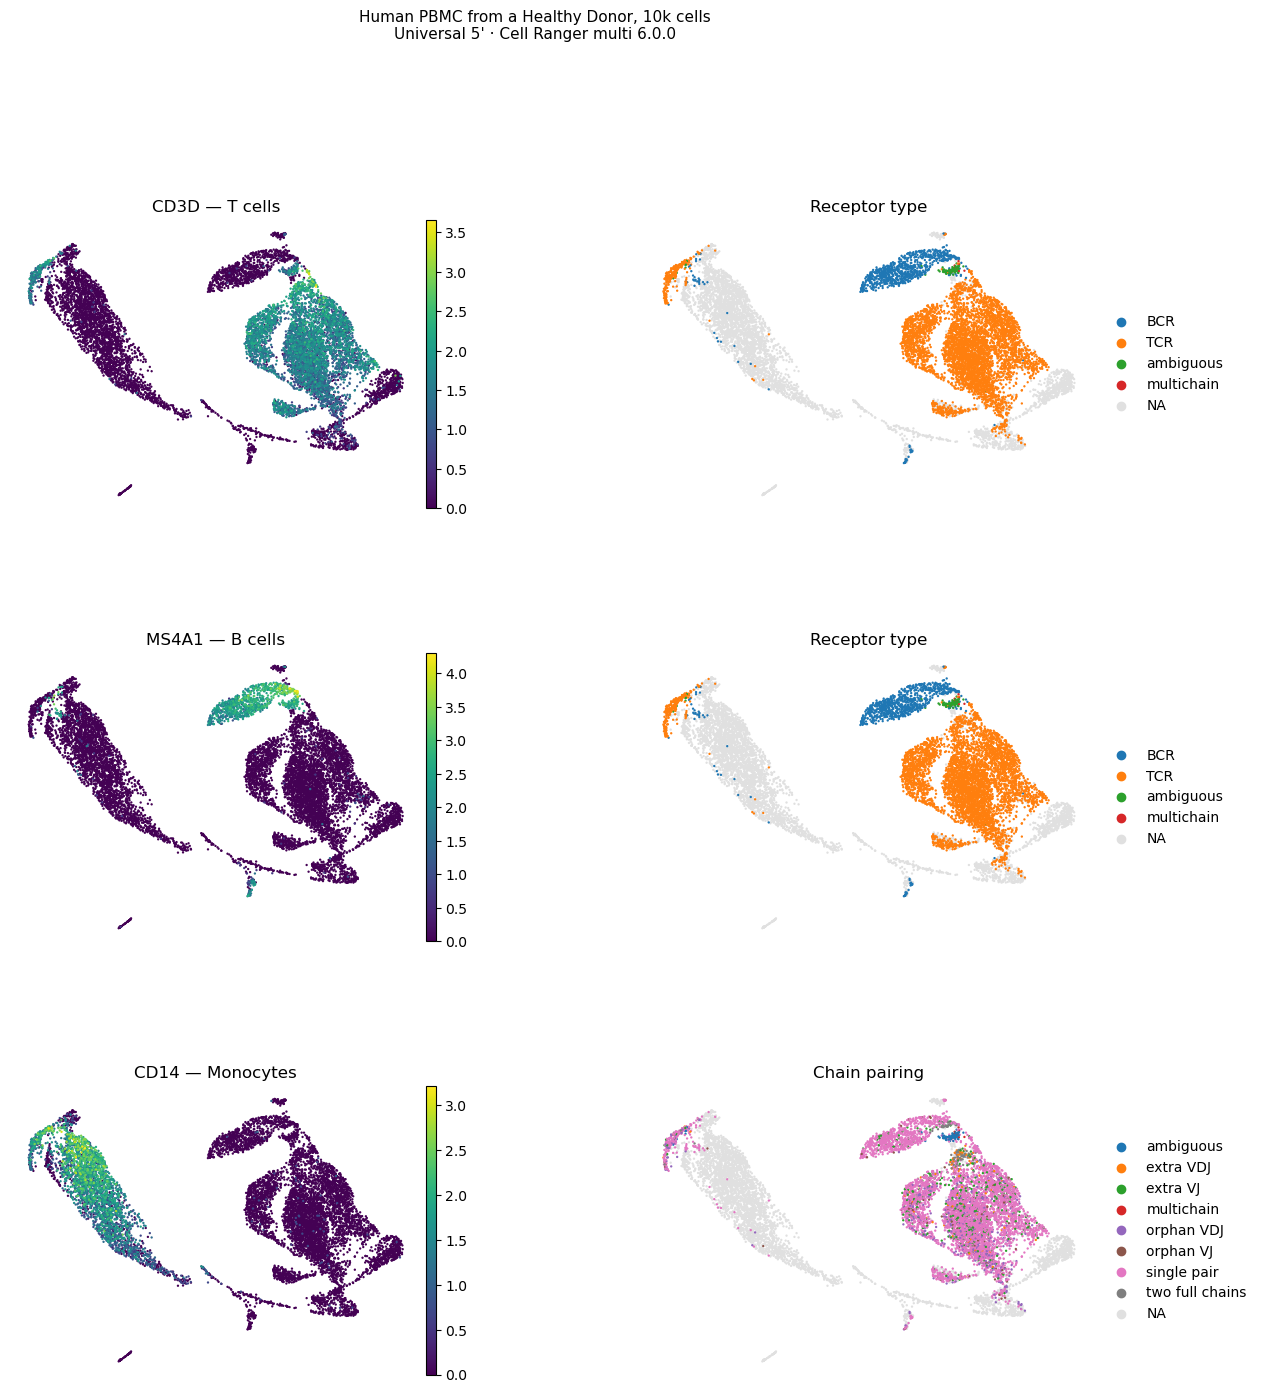

In [20]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15), gridspec_kw={"wspace": 0.4, "hspace": 0.5})

mu.pl.embedding(
    mdata,
    basis="gex:umap",
    color=["CD3D"],
    ax=axes[0, 0],
    show=False,
    title="CD3D — T cells",
    colorbar_loc="right",
    frameon=False,
)

mu.pl.embedding(
    mdata,
    basis="gex:umap",
    color=["airr:receptor_type"],
    ax=axes[0, 1],
    show=False,
    title="Receptor type",
    frameon=False,
    na_color="#e0e0e0",
)

mu.pl.embedding(
    mdata,
    basis="gex:umap",
    color=["MS4A1"],
    ax=axes[1, 0],
    show=False,
    title="MS4A1 — B cells",
    colorbar_loc="right",
    frameon=False,
)

mu.pl.embedding(
    mdata,
    basis="gex:umap",
    color=["airr:receptor_type"],
    ax=axes[1, 1],
    show=False,
    title="Receptor type",
    frameon=False,
    na_color="#e0e0e0",
)

mu.pl.embedding(
    mdata,
    basis="gex:umap",
    color=["CD14"],
    ax=axes[2, 0],
    show=False,
    title="CD14 — Monocytes",
    colorbar_loc="right",
    frameon=False,
)

mu.pl.embedding(
    mdata,
    basis="gex:umap",
    color=["airr:chain_pairing"],
    ax=axes[2, 1],
    show=False,
    title="Chain pairing",
    frameon=False,
    na_color="#e0e0e0",
)

fig.suptitle(
    "Human PBMC from a Healthy Donor, 10k cells\n"
    "Universal 5' · Cell Ranger multi 6.0.0",
    fontsize=11,
    y=1.02,
)

plt.show()